## BBH diagram

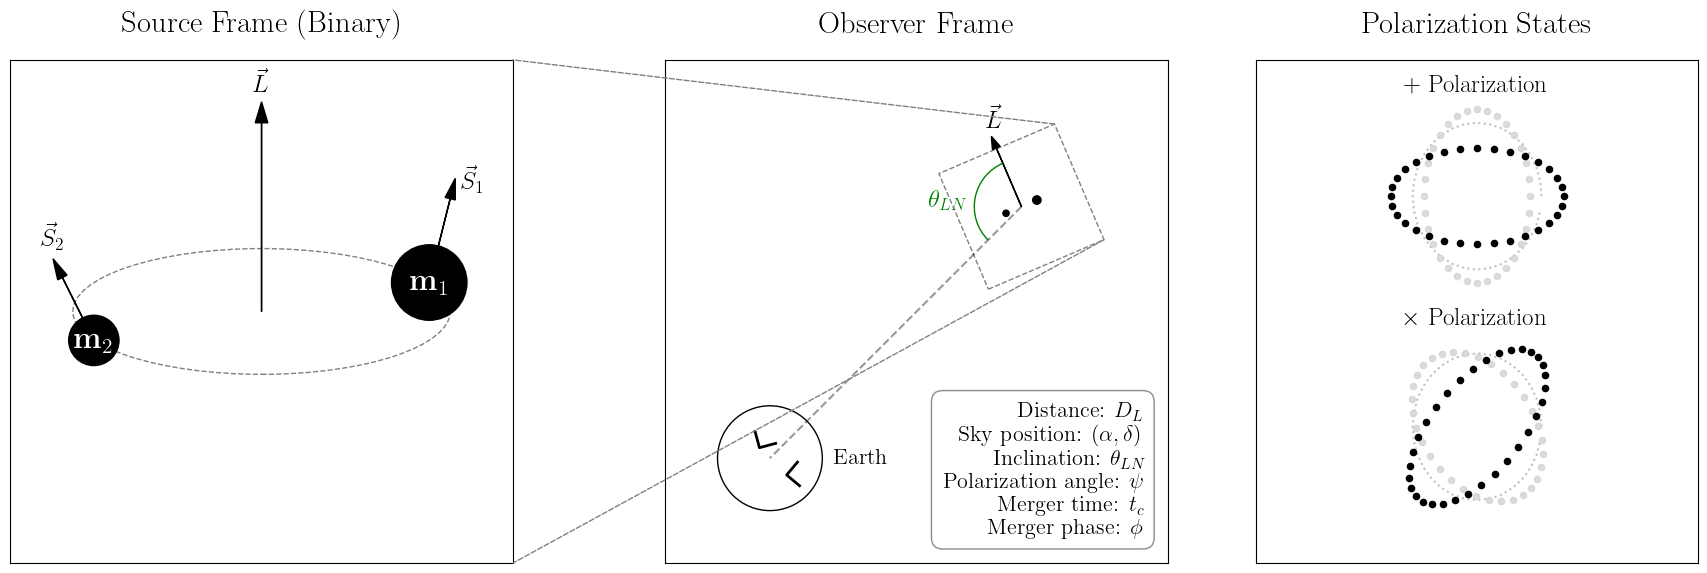

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse, Circle, Rectangle, ConnectionPatch, Arc

# --- Global Parameter Adjustments ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "ytick.direction": "in",
    "xtick.top": True,
    "xtick.bottom": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

vector_color = 'black'

# Create a figure with custom width ratios
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1, 0.7]})
ax1, ax2, ax3 = axes

# Formatting axes
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

# Enforce square aspect ratio for Panels 1 and 2
ax1.set_aspect('equal')
ax2.set_aspect('equal')

# ==========================================
# Panel 1: Source Frame (Zoomed in)
# ==========================================
ax1.set_title("Merger frame (intrinsic)", pad=20, fontsize=16)

# Orbital ellipse: Made completely horizontal
orbit = Ellipse((0, 0), 1.8, 0.6, angle=0, fill=False, linestyle='--', color='gray')
ax1.add_patch(orbit)

# Black holes: Scaled down to ~half size, accurately placed on the orbital path
bh1_pos = (0.8, 0.138)  # Calculated to lie on the a=0.9, b=0.3 ellipse
bh2_pos = (-0.8, -0.138)
ax1.add_patch(Circle(bh1_pos, 0.18, color='black', zorder=3))
ax1.add_patch(Circle(bh2_pos, 0.12, color='black', zorder=3))

# White bold text labels directly inside the black circles, with increased font size
ax1.text(bh1_pos[0], bh1_pos[1], r"$\mathbf{m}_1$", fontsize=16, color='white', ha='center', va='center', zorder=4)
ax1.text(bh2_pos[0], bh2_pos[1], r"$\mathbf{m}_2$", fontsize=16, color='white', ha='center', va='center', zorder=4)

# Orbital angular momentum vector (L): Perpendicular to the horizontal orbit
ax1.arrow(0, 0, 0, 0.9, head_width=0.06, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
ax1.text(0, 1.05, r"$\vec{L}$", color=vector_color, fontsize=16, ha='center')

# Spin vectors (S1, S2)
ax1.arrow(bh1_pos[0], bh1_pos[1], 0.1, 0.4, head_width=0.05, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
ax1.text(bh1_pos[0] + 0.15, bh1_pos[1] + 0.45, r"$\vec{S}_1$", color=vector_color, fontsize=16)

ax1.arrow(bh2_pos[0], bh2_pos[1], -0.15, 0.3, head_width=0.05, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
# S2 label moved higher to avoid vector overlap
ax1.text(bh2_pos[0] - 0.25, bh2_pos[1] + 0.45, r"$\vec{S}_2$", color=vector_color, fontsize=16)

# ==========================================
# Panel 2: Observer Frame (Zoomed out)
# ==========================================
ax2.set_title("Observer frame (extrinsic)", pad=20, fontsize=16)

# Observer Earth
earth_center = (-0.7, -0.7)
earth_circle = Circle(earth_center, 0.25, fill=False, color='black')
ax2.add_patch(earth_circle)
ax2.text(earth_center[0] + 0.3, earth_center[1], "Earth", fontsize=16, color='black', va='center')

# Function to draw a right-angle interferometer (|_ shape)
def draw_ifo(ax, cx, cy, arm_length, angle_deg):
    x1 = cx + arm_length * np.cos(np.radians(angle_deg))
    y1 = cy + arm_length * np.sin(np.radians(angle_deg))
    x2 = cx + arm_length * np.cos(np.radians(angle_deg + 90))
    y2 = cy + arm_length * np.sin(np.radians(angle_deg + 90))
    ax.plot([x1, cx, x2], [y1, cy, y2], color='black', lw=2)

# Draw two independently tilted interferometers inside the Earth
draw_ifo(ax2, -0.75, -0.65, 0.08, 15)   # IFO 1
draw_ifo(ax2, -0.62, -0.78, 0.08, -40)  # IFO 2

# Calculate rotation for the inset box based on L vector
box_x, box_y = 0.5, 0.5
box_w, box_h = 0.6, 0.6

# Shrink L vector
L_dx, L_dy = -0.12, 0.28
angle_L_deg = np.degrees(np.arctan2(L_dy, L_dx))
box_angle = angle_L_deg - 90  # Box rotation matches the tilt of L relative to vertical

# Rotate and draw the inset box using Affine2D
rect = Rectangle((box_x - box_w/2, box_y - box_h/2), box_w, box_h, fill=False, color='gray', linestyle='--')
t = transforms.Affine2D().rotate_deg_around(box_x, box_y, box_angle) + ax2.transData
rect.set_transform(t)
ax2.add_patch(rect)

# Draw a very small binary inside the inset box, respecting the rotation
orbit_dx = 0.08 * np.cos(np.radians(box_angle))
orbit_dy = 0.08 * np.sin(np.radians(box_angle))
ax2.add_patch(Circle((box_x + orbit_dx, box_y + orbit_dy), 0.02, color='black'))
ax2.add_patch(Circle((box_x - orbit_dx, box_y - orbit_dy), 0.015, color='black'))

# L vector in Panel 2
ax2.arrow(box_x, box_y, L_dx, L_dy, head_width=0.04, head_length=0.06, fc=vector_color, ec=vector_color)
ax2.text(box_x + L_dx - 0.05, box_y + L_dy + 0.1, r"$\vec{L}$", color=vector_color, fontsize=16)

# Line of sight vector (\hat{N}) connecting binary to Earth
ax2.plot([box_x, earth_center[0]], [box_y, earth_center[1]], 'k--', alpha=0.4)
# Arrow head placed midway along the path
mid_x, mid_y = (box_x + earth_center[0])/2, (box_y + earth_center[1])/2
N_dx, N_dy = earth_center[0] - box_x, earth_center[1] - box_y
N_len = np.hypot(N_dx, N_dy)
# ax2.arrow(box_x - 0.15, box_y - 0.15, N_dx/N_len * 0.15, N_dy/N_len * 0.15, head_width=0.04, head_length=0.06, fc='k', ec='k')
# ax2.text(box_x - 0.2, box_y - 0.35, r"$\hat{N}$", fontsize=16)

# Inclination angle arc (\theta_{LN})
angle_N_deg = np.degrees(np.arctan2(N_dy, N_dx)) % 360
arc = Arc((box_x, box_y), 0.45, 0.45, angle=0, theta1=angle_L_deg, theta2=angle_N_deg, color='green')
ax2.add_patch(arc)
# Position the theta_{LN} label cleanly within the arc
lbl_angle = np.radians((angle_L_deg + angle_N_deg) / 2)
ax2.text(box_x + 0.3 * np.cos(lbl_angle) - 0.15, box_y + 0.3 * np.sin(lbl_angle) - 0.05, r"$\theta_{LN}$", color='green', fontsize=16)

# Information Text
info_text = ("Distance: $D_L$\n"
             "Sky position: $(\\alpha, \\delta)$\n"
             "Inclination: $\\theta_{LN}$\n"
             "Polarization angle: $\\psi$\n"
             "Merger time: $t_c$\n"
             "Merger phase: $\phi$"
             )
ax2.text(0.95, 0.05, info_text, 
         transform=ax2.transAxes, 
         fontsize=16, 
         ha='right', 
         va='bottom',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# Calculate exact right-side corners of the rotated box for connection patches
box_rad = np.radians(box_angle)
c, s = np.cos(box_rad), np.sin(box_rad)
def get_rotated_corner(x_offset, y_offset):
    return box_x + x_offset*c - y_offset*s, box_y + x_offset*s + y_offset*c

# Right corners in the rotated frame
top_right = get_rotated_corner(box_w/2, box_h/2)
bottom_right = get_rotated_corner(box_w/2, -box_h/2)

con1 = ConnectionPatch(xyA=top_right, coordsA=ax2.transData,
                       xyB=(1.2, 1.2), coordsB=ax1.transData, color="gray", linestyle="--")
con2 = ConnectionPatch(xyA=bottom_right, coordsA=ax2.transData,
                       xyB=(1.2, -1.2), coordsB=ax1.transData, color="gray", linestyle="--")
fig.add_artist(con1)
fig.add_artist(con2)

# ==========================================
# Panel 3: Polarization States
# ==========================================
ax3.set_title("Polarization States", pad=20, fontsize=16)
theta = np.linspace(0, 2*np.pi, 32, endpoint=False)
r = 0.35
point_color = 'black'
reference_color = 'gray'
phase_color = 'lightgray'

def draw_polarization_state(ax, center_y, title, perturb_x, perturb_y, text_y):
    # Reference
    x_ref = r * np.cos(theta)
    y_ref = r * np.sin(theta) + center_y
    ax.plot(x_ref, y_ref, ':', color=reference_color, alpha=0.5)

    # Dark phase
    x_pert1 = (r + perturb_x * 1.5) * np.cos(theta)
    y_pert1 = (r + perturb_y * 1.5) * np.sin(theta) + center_y

    # Light phase
    x_pert2 = (r - perturb_x * 0.8) * np.cos(theta)
    y_pert2 = (r - perturb_y * 0.8) * np.sin(theta) + center_y

    ax.scatter(x_pert2, y_pert2, color=phase_color, s=20, alpha=0.8, zorder=4)
    ax.scatter(x_pert1, y_pert1, color=point_color, s=20, zorder=5)

    # Increased separation by placing text explicitly at 'text_y'
    ax.text(0, text_y, title, ha='center', fontsize=16)

# Plus Polarization
perturb_plus_x = 0.08
perturb_plus_y = -0.08
draw_polarization_state(ax3, 0.55, r"$+$ Polarization", perturb_plus_x, perturb_plus_y, text_y=1.05)

# Cross Polarization (Requires rotating the plus pattern)
x_cross1 = (r + perturb_plus_x * 1.5) * np.cos(theta)
y_cross1 = (r - perturb_plus_x * 1.5) * np.sin(theta)
x_cross2 = (r - perturb_plus_x * 0.8) * np.cos(theta)
y_cross2 = (r + perturb_plus_x * 0.8) * np.sin(theta)

ang = np.pi/4
x_cp1 = x_cross1 * np.cos(ang) - y_cross1 * np.sin(ang)
y_cp1 = x_cross1 * np.sin(ang) + y_cross1 * np.cos(ang) - 0.55
x_cp2 = x_cross2 * np.cos(ang) - y_cross2 * np.sin(ang)
y_cp2 = x_cross2 * np.sin(ang) + y_cross2 * np.cos(ang) - 0.55

x_ref_x = r * np.cos(theta)
y_ref_x = r * np.sin(theta) - 0.55
ax3.plot(x_ref_x, y_ref_x, ':', color=reference_color, alpha=0.5)

ax3.scatter(x_cp2, y_cp2, color=phase_color, s=20, alpha=0.8, zorder=4)
ax3.scatter(x_cp1, y_cp1, color=point_color, s=20, zorder=5)
# Text pushed further down for separation
ax3.text(0, -0.05, r"$\times$ Polarization", ha='center', fontsize=16)

plt.tight_layout()
plt.show()
# plt.savefig('bbh_merger_diagram_v3.pdf', dpi=300)

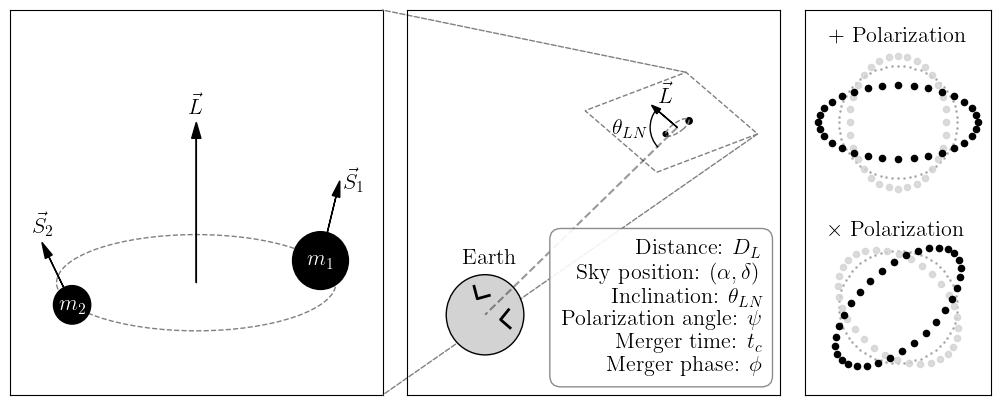

In [126]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse, Circle, Rectangle, ConnectionPatch, Arc

# --- Global Parameter Adjustments ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "ytick.direction": "in",
    "xtick.top": True,
    "xtick.bottom": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

vector_color = 'black'

# Create a figure with custom width ratios

if True:
    fig, axes = plt.subplots(1, 3, figsize=(12.66, 5), gridspec_kw={'width_ratios': [1, 1, 0.5], 'wspace': 0.08})
    ax1, ax2, ax3 = axes

    # Formatting axes
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)

    # Enforce square aspect ratio for Panels 1 and 2
    # ax1.set_aspect('equal')
    # ax2.set_aspect('equal')
    ax3.set_xlim(-0.55,0.55)
else:
    # Use GridSpec to define custom widths and spacing
    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(1, 3, height_ratios=[1], width_ratios=[1, 1, 0.5], wspace=0.05)

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])

    # Formatting Panels 1 and 2 (Square Data Limits)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_aspect('equal')

    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')

    # Formatting Panel 3 (Taller Data Limits, but keeping Aspect Equal)
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.set_xlim(-0.6,0.6)
    # Increased y-limits stretch the box vertically, but aspect='equal' 
    # ensures circles remain perfect circles.
    ax3.set_ylim(-1.2, 1.2) 

# ==========================================
# Panel 1: Source Frame (Zoomed in)
# ==========================================
# ax1.set_title("Merger frame (intrinsic)", pad=20, fontsize=16)

yshift = 0.5
# Orbital ellipse: Made completely horizontal
orbit = Ellipse((0, -yshift), 1.8, 0.6, angle=0, fill=False, linestyle='--', color='gray')
ax1.add_patch(orbit)

# Black holes: Scaled down to ~half size, accurately placed on the orbital path
bh1_pos = (0.8, 0.138-yshift)  # Calculated to lie on the a=0.9, b=0.3 ellipse
bh2_pos = (-0.8, -0.138-yshift)
ax1.add_patch(Circle(bh1_pos, 0.18, color='black', zorder=3))
ax1.add_patch(Circle(bh2_pos, 0.12, color='black', zorder=3))

# White bold text labels directly inside the black circles, with increased font size
ax1.text(bh1_pos[0], bh1_pos[1], r"$m_1$", fontsize=16, color='white', ha='center', va='center', zorder=4)
ax1.text(bh2_pos[0], bh2_pos[1], r"$m_2$", fontsize=16, color='white', ha='center', va='center', zorder=4)

# Orbital angular momentum vector (L): Perpendicular to the horizontal orbit
ax1.arrow(0, -yshift, 0, 0.9, head_width=0.06, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
ax1.text(0, 1.05 -yshift, r"$\vec{L}$", color=vector_color, fontsize=16, ha='center')

# Spin vectors (S1, S2)
ax1.arrow(bh1_pos[0], bh1_pos[1], 0.1, 0.4, head_width=0.05, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
ax1.text(bh1_pos[0] + 0.15, bh1_pos[1] + 0.45, r"$\vec{S}_1$", color=vector_color, fontsize=16)

ax1.arrow(bh2_pos[0], bh2_pos[1], -0.15, 0.3, head_width=0.05, head_length=0.1, fc=vector_color, ec=vector_color, zorder=2)
# S2 label moved higher to avoid vector overlap
ax1.text(bh2_pos[0] - 0.25, bh2_pos[1] + 0.45, r"$\vec{S}_2$", color=vector_color, fontsize=16)

# ==========================================
# Panel 2: Observer Frame (Zoomed out)
# ==========================================
# ax2.set_title("Observer frame (extrinsic)", pad=20, fontsize=16)

# Observer Earth
earth_center = (-0.7, -0.7)
earth_circle = Circle(earth_center, 0.25, fill=True, facecolor='lightgray', edgecolor='black')
ax2.add_patch(earth_circle)
ax2.text(earth_center[0] - 0.15, earth_center[1] + 0.35, "Earth", fontsize=16, color='black', va='center')

# Function to draw a right-angle interferometer (|_ shape)
def draw_ifo(ax, cx, cy, arm_length, angle_deg):
    x1 = cx + arm_length * np.cos(np.radians(angle_deg))
    y1 = cy + arm_length * np.sin(np.radians(angle_deg))
    x2 = cx + arm_length * np.cos(np.radians(angle_deg + 90))
    y2 = cy + arm_length * np.sin(np.radians(angle_deg + 90))
    ax.plot([x1, cx, x2], [y1, cy, y2], color='black', lw=2)

# Draw two independently tilted interferometers inside the Earth
draw_ifo(ax2, -0.75, -0.6, 0.08, 15)   # IFO 1
draw_ifo(ax2, -0.6, -0.73, 0.08, -40)  # IFO 2

box_x, box_y = 0.5, 0.5
box_w, box_h = 0.6, 0.6

# Shrink L vector and make it point more towards Earth (out of the plane)
# This reduces the theta_LN angle visibly
L_dx, L_dy = -0.12, 0.1
angle_L_deg = np.degrees(np.arctan2(L_dy, L_dx))
box_angle = angle_L_deg - 90  
skew = -30
# Create an affine transform for the inset box to make it a parallelogram (skewed)
# This simulates the 3D perspective of the plane tilting towards Earth
t_geom = transforms.Affine2D().skew_deg(0, skew).rotate_deg(box_angle).translate(box_x, box_y)

# Rotate, skew, and draw the inset box using the affine transformation
rect = Rectangle((-box_w/2, -box_h/2), box_w, box_h, fill=False, color='gray', linestyle='--')
rect.set_transform(t_geom + ax2.transData)
ax2.add_patch(rect)

# Unpack the resulting coordinate pair directly
inset_xshift, inset_yshift = t_geom.transform_point([0, -yshift/10]) - t_geom.transform_point([0, 0])

# Draw a very small binary inside the inset box, mapping their coordinates through the same transform
bh1_pt = t_geom.transform_point([0.08, 0.0138 - yshift/10])
bh2_pt = t_geom.transform_point([-0.08, -0.0138 - yshift/10])
ax2.add_patch(Circle(bh1_pt, 0.02, color='black'))
ax2.add_patch(Circle(bh2_pt, 0.015, color='black'))

orbit_inset = Ellipse((0, -yshift / 10), 0.18, 0.06, angle=box_angle+skew, fill=False, linestyle='--', color='gray')
orbit_inset.set_transform(t_geom + ax2.transData)
ax2.add_patch(orbit_inset)

# L vector in Panel 2
ax2.arrow(box_x+inset_xshift, box_y+inset_yshift, L_dx, L_dy, head_width=0.04, head_length=0.06, fc=vector_color, ec=vector_color)
ax2.text(box_x+inset_xshift + L_dx, box_y + L_dy + 0.05 +inset_yshift, r"$\vec{L}$", color=vector_color, fontsize=16)

# Line of sight vector (\hat{N}) connecting binary to Earth
ax2.plot([box_x+inset_xshift, earth_center[0]], [box_y+inset_yshift, earth_center[1]], 'k--', alpha=0.4)
# Arrow head placed midway along the path (uncommented to visualize the angle properly)
N_dx, N_dy = earth_center[0] - box_x, earth_center[1] - box_y
N_len = np.hypot(N_dx, N_dy)
# ax2.arrow(box_x - 0.15, box_y - 0.15, N_dx/N_len * 0.15, N_dy/N_len * 0.15, head_width=0.04, head_length=0.06, fc='k', ec='k')
# ax2.text(box_x - 0.2, box_y - 0.35, r"$\hat{N}$", fontsize=16)

# Inclination angle arc (\theta_{LN}) - calculated to always take the short path cleanly
a_L = np.degrees(np.arctan2(L_dy, L_dx))
a_N = np.degrees(np.arctan2(N_dy, N_dx))
t1, t2 = min(a_L, a_N), max(a_L, a_N)
if t2 - t1 > 180:
    theta1 = t2
    theta2 = t1 + 360
else:
    theta1 = t1
    theta2 = t2

arc = Arc((box_x + inset_xshift, box_y + inset_yshift), 0.35, 0.35, angle=0, theta1=theta1, theta2=theta2, color='black')
ax2.add_patch(arc)

# Position the theta_{LN} label cleanly within the arc bounds
lbl_angle = np.radians((theta1 + theta2) / 2)
ax2.text(box_x + 0.3 * np.cos(lbl_angle) + inset_xshift - 0.015, box_y + 0.3 * np.sin(lbl_angle) + inset_yshift, r"$\theta_{LN}$", color='black', fontsize=16, ha='center', va='center')

# Information Text
info_text = ("Distance: $D_L$\n"
             "Sky position: $(\\alpha, \\delta)$\n"
             "Inclination: $\\theta_{LN}$\n"
             "Polarization angle: $\\psi$\n"
             "Merger time: $t_c$\n"
             "Merger phase: $\phi$"
             )
ax2.text(0.95, 0.05, info_text, 
         transform=ax2.transAxes, 
         fontsize=16, 
         ha='right', 
         va='bottom',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'), zorder=10)

# Extract exact transformed corners of the parallelogram for accurate connection patches
top_right_base = [box_w/2, box_h/2]
bottom_right_base = [box_w/2, -box_h/2]
top_right = t_geom.transform_point(top_right_base)
bottom_right = t_geom.transform_point(bottom_right_base)

con1 = ConnectionPatch(xyA=top_right, coordsA=ax2.transData,
                       xyB=(1.2, 1.2), coordsB=ax1.transData, color="gray", linestyle="--", zorder=0)
con2 = ConnectionPatch(xyA=bottom_right, coordsA=ax2.transData,
                       xyB=(1.2, -1.2), coordsB=ax1.transData, color="gray", linestyle="--", zorder=0)

con1.set_clip_on(False)
con2.set_clip_on(False)

# 3. Add them to ax2 (NOT fig)
ax2.add_artist(con1)
ax2.add_artist(con2)

# ==========================================
# Panel 3: Polarization States
# ==========================================
# ax3.set_title("Polarization States", pad=20, fontsize=16)
theta = 2*np.pi * np.arange(0, 1, 1/32)
r = 0.35
point_color = 'black'
reference_color = 'gray'
phase_color = 'lightgray'

def draw_polarization_state(ax, center_y, title, perturb_x, perturb_y, text_y):

    # Dark phase
    x_pert1 = (r + perturb_x * 1.5) * np.cos(theta)
    y_pert1 = (r + perturb_y * 1.5) * np.sin(theta) + center_y

    # Light phase
    x_pert2 = (r - perturb_x * 0.8) * np.cos(theta)
    y_pert2 = (r - perturb_y * 0.8) * np.sin(theta) + center_y

    ax.scatter(x_pert2, y_pert2, color=phase_color, s=20, alpha=0.8, zorder=4)
    ax.scatter(x_pert1, y_pert1, color=point_color, s=20, zorder=5)

    # Increased separation by placing text explicitly at 'text_y'
    ax.text(0, text_y, title, ha='center', fontsize=16)

# Plus Polarization
perturb_plus_x = 0.08
perturb_plus_y = -0.08
draw_polarization_state(ax3, 0.5, r"$+$ Polarization", perturb_plus_x, perturb_plus_y, text_y=1.0)

# Cross Polarization (Requires rotating the plus pattern)
x_cross1 = (r + perturb_plus_x * 1.5) * np.cos(theta)
y_cross1 = (r - perturb_plus_x * 1.5) * np.sin(theta)
x_cross2 = (r - perturb_plus_x * 0.8) * np.cos(theta)
y_cross2 = (r + perturb_plus_x * 0.8) * np.sin(theta)

ang = np.pi/4
x_cp1 = x_cross1 * np.cos(ang) - y_cross1 * np.sin(ang)
y_cp1 = x_cross1 * np.sin(ang) + y_cross1 * np.cos(ang) - 0.65
x_cp2 = x_cross2 * np.cos(ang) - y_cross2 * np.sin(ang)
y_cp2 = x_cross2 * np.sin(ang) + y_cross2 * np.cos(ang) - 0.65

x_ref_x = r * np.cos(2*np.pi*np.arange(0,1,1/64))
y_ref_x = r * np.sin(2*np.pi*np.arange(0,1,1/64))

ax3.scatter(x_ref_x, y_ref_x + 0.5, s=1, color=reference_color, alpha=0.5)
ax3.scatter(x_ref_x, y_ref_x - 0.65, s=1, color=reference_color, alpha=0.5)

ax3.scatter(x_cp2, y_cp2, color=phase_color, s=20, alpha=0.8, zorder=4)
ax3.scatter(x_cp1, y_cp1, color=point_color, s=20, zorder=5)
# Text pushed further down for separation
ax3.text(0, -0.2, r"$\times$ Polarization", ha='center', fontsize=16)

# plt.show()
plt.savefig('bbh_merger_diagram.pdf', dpi=300, bbox_inches='tight')

In [109]:
np.arange(0, 1, 1/32)

array([0.     , 0.03125, 0.0625 , 0.09375, 0.125  , 0.15625, 0.1875 ,
       0.21875, 0.25   , 0.28125, 0.3125 , 0.34375, 0.375  , 0.40625,
       0.4375 , 0.46875, 0.5    , 0.53125, 0.5625 , 0.59375, 0.625  ,
       0.65625, 0.6875 , 0.71875, 0.75   , 0.78125, 0.8125 , 0.84375,
       0.875  , 0.90625, 0.9375 , 0.96875])